# Analisi Classificazione tramite Regex

Questo notebook implementa una classificazione binaria *AI* / *NON AI* utilizzando un'espressione regolare mirata. L'elaborazione avviene su **10 thread simultanei** e processa i file CSV in modalità **lazy (a chunk)** per garantire un occupazione di memoria quasi nulla (Zero Memory Footprint).

Alla fine viene generata una **matrice di confusione** aggregando i risultati distribuiti per confrontare la predizione della Regex contro la colonna `CLASSIFICAZIONE` pre-calcolata.

In [50]:
import pandas as pd
import numpy as np
import re
import glob
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Setup & Regex

In [51]:
# Configurazione percorsi e thread
DATA_DIR = '../data'
FILE_PATTERN = 'classified_multiclass_aiuti_*.csv'
MAX_WORKERS = 10
CHUNK_SIZE = 100000

# Regex per rilevare AI (minimizzando i falsi positivi)
# Usiamo (?i:...) per rendere l'elenco principale case-insensitive, pur mantenendo AI e IA strettamente case-sensitive per non prendere le preposizioni.
AI_REGEX_PATTERN = r'(?i:\b(apprendimento automatico|intelligenza artificiale|robotica collaborative|visione artificiale|algoritmi predittivi|manutenzione preventiva|big data|intelligenza artificiale|machine learning|deep learning|reti neurali|computer vision|ai generativa|elaborazione del linguaggio naturale|nlp|llm|virtual assistant|virtual assistants|realtà virtuale| realtà aumentata|virtual reality|augmented reality|augmented reality|guida autonoma|drone|chatbot|classificazione semantica)\b)|\b(IA|tecnologie AI|tecnologie IA|modelli di AI|algoritmi di AI|algoritmi di IA|LLM)\b'
ai_regex = re.compile(AI_REGEX_PATTERN)

## 2. Funzione di Processing (Lazy)

In [52]:
def process_file(filepath):
    print(f"Elaborazione avviata: {os.path.basename(filepath)}")
    
    # Inizializza contatori (True Positive, False Positive, True Negative, False Negative)
    # Assumiamo AI = Positive Class
    tp, fp, tn, fn = 0, 0, 0, 0
    top_fn_records = pd.DataFrame()
    top_fp_records = pd.DataFrame()
    
    try:
        # Lettura Lazy Chunked. Vengono estratte unicamente le colonne necessarie al processing.
        chunk_iter = pd.read_csv(
            filepath, 
            chunksize=CHUNK_SIZE, 
            usecols=['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA'],
            dtype=str
        )
        
        for chunk in chunk_iter:
            # Sanitizzazione e parsing stringhe base
            desc = chunk['DESCRIZIONE_PROGETTO'].fillna('')
            current_classification = chunk['CLASSIFICAZIONE'].fillna('NON_AI').str.upper()
            chunk['CLASSIFICAZIONE_CONFIDENZA'] = pd.to_numeric(chunk['CLASSIFICAZIONE_CONFIDENZA'], errors='coerce').fillna(0.0)
            
            # Predizione Regex: True se troviamo il pattern, False altrimenti
            regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
            
            # Ground Truth (dal file CSV)
            true_labels = (current_classification == 'AI')
            
            # Update metriche
            tp += ((regex_preds == True) & (true_labels == True)).sum()
            fp += ((regex_preds == True) & (true_labels == False)).sum()
            tn += ((regex_preds == False) & (true_labels == False)).sum()
            fn += ((regex_preds == False) & (true_labels == True)).sum()
            
            # Estrazione False Negatives con confidenza > 0.9
            fn_mask = (regex_preds == False) & (true_labels == True) & (chunk['CLASSIFICAZIONE_CONFIDENZA'] > 0.9)
            if fn_mask.any():
                fn_chunk = chunk[fn_mask]
                top_fn_records = pd.concat([top_fn_records, fn_chunk])
                
            # Estrazione False Positives con confidenza > 0.9
            fp_mask = (regex_preds == True) & (true_labels == False) & (chunk['CLASSIFICAZIONE_CONFIDENZA'] > 0.9)
            if fp_mask.any():
                fp_chunk = chunk[fp_mask]
                top_fp_records = pd.concat([top_fp_records, fp_chunk])
            
    except Exception as e:
        print(f"Errore in {filepath}: {e}")
        return None
        
    print(f"Completato: {os.path.basename(filepath)} | TP:{tp} FP:{fp} TN:{tn} FN:{fn}")
    return {
        'file': os.path.basename(filepath),
        'tp': tp,        'fp': fp,
        'tn': tn,        'fn': fn,
        'top_fns': top_fn_records,
        'top_fps': top_fp_records
    }

## 3. Multithreading Execution

In [53]:
files = glob.glob(os.path.join(DATA_DIR, FILE_PATTERN))
print(f"\nTrovati {len(files)} file per il processing concorrente su 10 thread.")

results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Assegna i task ai worker nel thread pool
    futures = {executor.submit(process_file, f): f for f in files}
    
    for future in as_completed(futures):
        res = future.result()
        if res:
            results.append(res)

print("\nTutti i thread sono stati completati con successo.")


Trovati 12 file per il processing concorrente su 10 thread.
Elaborazione avviata: classified_multiclass_aiuti_2016.csv
Elaborazione avviata: classified_multiclass_aiuti_2017.csv
Elaborazione avviata: classified_multiclass_aiuti_2015.csv
Elaborazione avviata: classified_multiclass_aiuti_2014.csv
Elaborazione avviata: classified_multiclass_aiuti_2025.csv
Elaborazione avviata: classified_multiclass_aiuti_2019.csv
Elaborazione avviata: classified_multiclass_aiuti_2018.csv
Elaborazione avviata: classified_multiclass_aiuti_2024.csv
Elaborazione avviata: classified_multiclass_aiuti_2023.csv
Elaborazione avviata: classified_multiclass_aiuti_2022.csv
Completato: classified_multiclass_aiuti_2015.csv | TP:0 FP:1 TN:2297 FN:1
Elaborazione avviata: classified_multiclass_aiuti_2020.csv
Completato: classified_multiclass_aiuti_2016.csv | TP:11 FP:2 TN:8362 FN:3
Elaborazione avviata: classified_multiclass_aiuti_2021.csv
Completato: classified_multiclass_aiuti_2014.csv | TP:0 FP:0 TN:15448 FN:0


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expre

Completato: classified_multiclass_aiuti_2017.csv | TP:39 FP:91 TN:214349 FN:67


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expre

Completato: classified_multiclass_aiuti_2019.csv | TP:297 FP:131 TN:513481 FN:356


...

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expre

Completato: classified_multiclass_aiuti_2021.csv | TP:233 FP:90 TN:3220439 FN:312


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expre

Completato: classified_multiclass_aiuti_2023.csv | TP:422 FP:114 TN:6477564 FN:611
Completato: classified_multiclass_aiuti_2024.csv | TP:2150 FP:666 TN:6018601 FN:867

Tutti i thread sono stati completati con successo.


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/2411073312.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)


## 4. Aggregazione e Matrice di Confusione

--- Risultati Totali Aggregati ---
Totale Record: 23,957,368
True Positives (TP): 6,987
False Positives (FP): 2,521
True Negatives (TN): 23,941,008
False Negatives (FN): 6,852



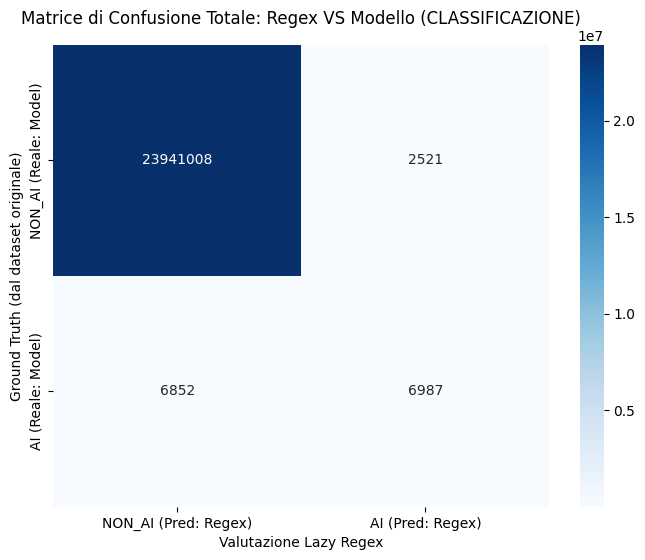

In [54]:
if not results:
    print("Nessun risultato disponibile da processare.")
else:
    # Aggregazione
    total_tp = sum(r['tp'] for r in results)
    total_fp = sum(r['fp'] for r in results)
    total_tn = sum(r['tn'] for r in results)
    total_fn = sum(r['fn'] for r in results)

    print("--- Risultati Totali Aggregati ---")
    print(f"Totale Record: {total_tp + total_fp + total_tn + total_fn:,}")
    print(f"True Positives (TP): {total_tp:,}")
    print(f"False Positives (FP): {total_fp:,}")
    print(f"True Negatives (TN): {total_tn:,}")
    print(f"False Negatives (FN): {total_fn:,}\n")
    
    # Matrice di Confusione
    conf_matrix = np.array([
        [total_tn, total_fp], 
        [total_fn, total_tp]
    ])
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=['NON_AI (Pred: Regex)', 'AI (Pred: Regex)'], 
        yticklabels=['NON_AI (Reale: Model)', 'AI (Reale: Model)']
    )
    
    plt.title('Matrice di Confusione Totale: Regex VS Modello (CLASSIFICAZIONE)', pad=15)
    plt.ylabel('Ground Truth (dal dataset originale)')
    plt.xlabel('Valutazione Lazy Regex')
    plt.show()

## 5. Analisi False Negatives ad Alta Confidenza

Analizziamo i progetti che il modello ha classificato come "AI" con un'elevata **CLASSIFICAZIONE_CONFIDENZA**, ma che la regex non è riuscita a catturare (Classificati preventivamente dalla regex come "NON_AI").

In [59]:
if results:
    # Aggrega tutti i dataframe dei false negatives trovati in ogni file
    all_fns = pd.concat([r['top_fns'] for r in results if 'top_fns' in r and not r['top_fns'].empty])
    
    if not all_fns.empty:
        # Ordina per confidenza discendente e visualizza i top 20
        top_fns_overall = all_fns.sort_values(by='CLASSIFICAZIONE_CONFIDENZA', ascending=False)
        
        print("I 20 progetti classificati 'AI' dal modello (con highest CONFIDENZA) ma mancati dalla regex:\n")
        for idx, row in top_fns_overall.head(20).iterrows():
            print(f"Confidenza: {row['CLASSIFICAZIONE_CONFIDENZA']:.4f}")
            desc = row['DESCRIZIONE_PROGETTO']
            if len(desc) > 500: desc = desc[:497] + "..."
            print(f"Descrizione: {desc}")
            print("-" * 80)
            
        # Esporta in CSV come richiesto (old = label modello, descrizione = desc. progetto)
        fn_export = all_fns[['CLASSIFICAZIONE', 'DESCRIZIONE_PROGETTO']].copy()
        fn_export.rename(columns={'CLASSIFICAZIONE': 'old', 'DESCRIZIONE_PROGETTO': 'descrizione'}, inplace=True)
        fn_export_path = os.path.join(DATA_DIR, 'regex_fn_mismatches.csv')
        fn_export.to_csv(fn_export_path, index=False, quoting=1)
        print(f"\n[+] Salvati {len(fn_export)} False Negatives (modello=AI, regex=NON_AI) in: {fn_export_path}")
        
    else:
        print("Nessun false negative trovato.")
else:
    print("Elaborazione non completata, risultati assenti.")

I 20 progetti classificati 'AI' dal modello (con highest CONFIDENZA) ma mancati dalla regex:

Confidenza: 0.9990
Descrizione: Fondata negli anni ’60, SIDERTAGLIO S.R.L. è specializzata nella lavorazione e taglio di lamiere metalliche. 
Il progetto DRAC mira ad una trasformazione digitale significativa dell’azienda attraverso l’adozione e/o l’implementazione delle seguenti soluzioni digitali e tecnologiche avanzate:
- Sistema di preventivazione automatica con AI per generare preventivi precisi e rapidi, ottimizzare il posizionamento dei pezzi da sagomare, migliorare l'efficienza operativa e la soddisfazione del clien...
--------------------------------------------------------------------------------
Confidenza: 0.9990
Descrizione: Sviluppa soluzioni tecnologiche avanzate per il riciclo dei rifiuti, integrando sensoristica intelligente e software AI dedicati per ottimizzare i processi di trattamento e ottenere materiali di valore in modo circolare.
---------------------------------------

## 6. Analisi False Positives ad Alta Confidenza

Analizziamo i progetti che il modello ha classificato come "NON_AI" con un'elevata **CLASSIFICAZIONE_CONFIDENZA** (> 0.9), ma che la regex ha classificato come "AI" (Falsi Positivi).

In [60]:
if results:
    # Aggrega tutti i dataframe dei false positives trovati in ogni file
    all_fps = pd.concat([r['top_fps'] for r in results if 'top_fps' in r and not r['top_fps'].empty])
    
    if not all_fps.empty:
        # Ordina per confidenza discendente (già filtrati con confidenza > 0.9)
        top_fps_overall = all_fps.sort_values(by='CLASSIFICAZIONE_CONFIDENZA', ascending=False)
        print("I progetti classificati 'NON_AI' dal modello (con highest CONFIDENZA > 0.9) che la regex ha classificato 'AI':\n")
        
        for idx, row in top_fps_overall.head(20).iterrows():
            print(f"Confidenza: {row['CLASSIFICAZIONE_CONFIDENZA']:.4f}")
            desc = row['DESCRIZIONE_PROGETTO']
            if pd.notna(desc) and len(desc) > 500: desc = desc[:497] + "..."
            print(f"Descrizione: {desc}")
            print("-" * 80)
            
        # Esporta in CSV come richiesto (old = label modello, descrizione = desc. progetto)
        fp_export = all_fps[['CLASSIFICAZIONE', 'DESCRIZIONE_PROGETTO']].copy()
        fp_export.rename(columns={'CLASSIFICAZIONE': 'old', 'DESCRIZIONE_PROGETTO': 'descrizione'}, inplace=True)
        fp_export_path = os.path.join(DATA_DIR, 'regex_fp_mismatches_hq.csv')
        fp_export.to_csv(fp_export_path, index=False, quoting=1)
        print(f"\n[+] Salvati {len(fp_export)} False Positives ad alta confidenza (modello=NON_AI, regex=AI) in: {fp_export_path}")
        
    else:
        print("Nessun false positive con confidenza > 0.9 trovato.")
else:
    print("Elaborazione non completata, risultati assenti.")

I progetti classificati 'NON_AI' dal modello (con highest CONFIDENZA > 0.9) che la regex ha classificato 'AI':

Confidenza: 0.9995
Descrizione: L'impresa proponente opera nel settore EDILE. Il progetto prevede l'ampliamento dell'attività mediante  l’acquisto di ponteggi per cantieri, di un furgone e di un drone per la razionalizzazione e  innovazione del processo produttivo. Investimento Ammesso: euro  81.005,10; Contributo concesso: euro  40.502,55
--------------------------------------------------------------------------------
Confidenza: 0.9995
Descrizione: Obiettivo del progetto e promuovere la digitalizzazione delle operazioni di manutenzione dei macchinari impiegati in campo per aumentarne l'efficienza e la sicurezza. In particolare gli addetti al settore produttivo e gestione operativa svilupperanno capacita nella gestione di macchinari e attrezzature adeguate ai diversi tipi di lavorazione del terreno. Acquisiranno capacita di eseguire interventi di manutenzione preventiva e co